In [1]:
pip install xgboost lightgbm pandas scikit-learn matplotlib seaborn shap


In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from google.colab import files
from xgboost import DMatrix
from xgboost import train
import seaborn as sns

In [3]:
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))



Saving Housing.csv to Housing.csv


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

target = 'price'
X = df.drop(columns=[target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)


In [8]:

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

dtrain = DMatrix(X_train, label=y_train)
dval = DMatrix(X_val, label=y_val)

model.fit(X_train,
          y_train,
          eval_set=[(X_val, y_val)],
          verbose=True)

[0]	validation_0-rmse:1731173.39300
[1]	validation_0-rmse:1689468.07596
[2]	validation_0-rmse:1655218.04729
[3]	validation_0-rmse:1625044.15012
[4]	validation_0-rmse:1593620.24920
[5]	validation_0-rmse:1568226.26919
[6]	validation_0-rmse:1534551.74747
[7]	validation_0-rmse:1506917.97119
[8]	validation_0-rmse:1478878.39558
[9]	validation_0-rmse:1449175.16565
[10]	validation_0-rmse:1424275.52634
[11]	validation_0-rmse:1401070.00449
[12]	validation_0-rmse:1381677.46876
[13]	validation_0-rmse:1365600.06458
[14]	validation_0-rmse:1343519.64225
[15]	validation_0-rmse:1327382.64075
[16]	validation_0-rmse:1311441.59165
[17]	validation_0-rmse:1292751.23123
[18]	validation_0-rmse:1280206.13651
[19]	validation_0-rmse:1264075.50415
[20]	validation_0-rmse:1257643.66357
[21]	validation_0-rmse:1243256.85726
[22]	validation_0-rmse:1232407.18276
[23]	validation_0-rmse:1221047.09891
[24]	validation_0-rmse:1210294.87887
[25]	validation_0-rmse:1200536.43283
[26]	validation_0-rmse:1191649.17143
[27]	valida

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
y_pred = model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred)
mse_xgb = mean_squared_error(y_test, y_pred)
r2_xgb = r2_score(y_test, y_pred)

print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("R²:", r2_xgb)

MAE: 960932.75
MSE: 1767623098368.0
R²: 0.6502920985221863


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)


In [11]:

mae_lr = mean_absolute_error(y_val, y_pred_lr)
mse_lr = mean_squared_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

print("\n Linear Regression:")
print(f"MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, R²: {r2_lr:.4f}")


 Linear Regression:
MAE: 979679.69, MSE: 1771751116594.04, R²: 0.6495


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=10, max_depth=6, random_state=42)

rf_model.fit(X_train_rf, y_train_rf)


y_pred_rf = rf_model.predict(X_val_rf)


In [13]:

mae_rf = mean_absolute_error(y_val_rf, y_pred_rf)
mse_rf = mean_squared_error(y_val_rf, y_pred_rf)
r2_rf = r2_score(y_val_rf, y_pred_rf)

print("\n Random Forest :")
print(f"MAE: {mae_rf:.2f}, MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")


 Random Forest :
MAE: 1078621.08, MSE: 1979910158971.79, R²: 0.61


In [14]:
print("\n So sánh các mô hình:")
print(f"{'Mô hình':<30} | {'MAE':<10} | {'MSE':<10} | {'R²':<10}")
print("-" * 65)

print(f"{'XGBoost  ':<30} | {mae_xgb:<10.2f} | {mse_xgb:<10.2f} | {r2_xgb:<10.4f}")
print(f"{'Linear Regression ':<30} | {mae_lr:<10.2f} | {mse_lr:<10.2f} | {r2_lr:<10.4f}")
print(f"{'Random Forest ':<30} | {mae_rf:<10.2f} | {mse_rf:<10.2f} | {r2_rf:<10.2f}")


 So sánh các mô hình:
Mô hình                        | MAE        | MSE        | R²        
-----------------------------------------------------------------
XGBoost                        | 960932.75  | 1767623098368.00 | 0.6503    
Linear Regression              | 979679.69  | 1771751116594.04 | 0.6495    
Random Forest                  | 1078621.08 | 1979910158971.79 | 0.61      


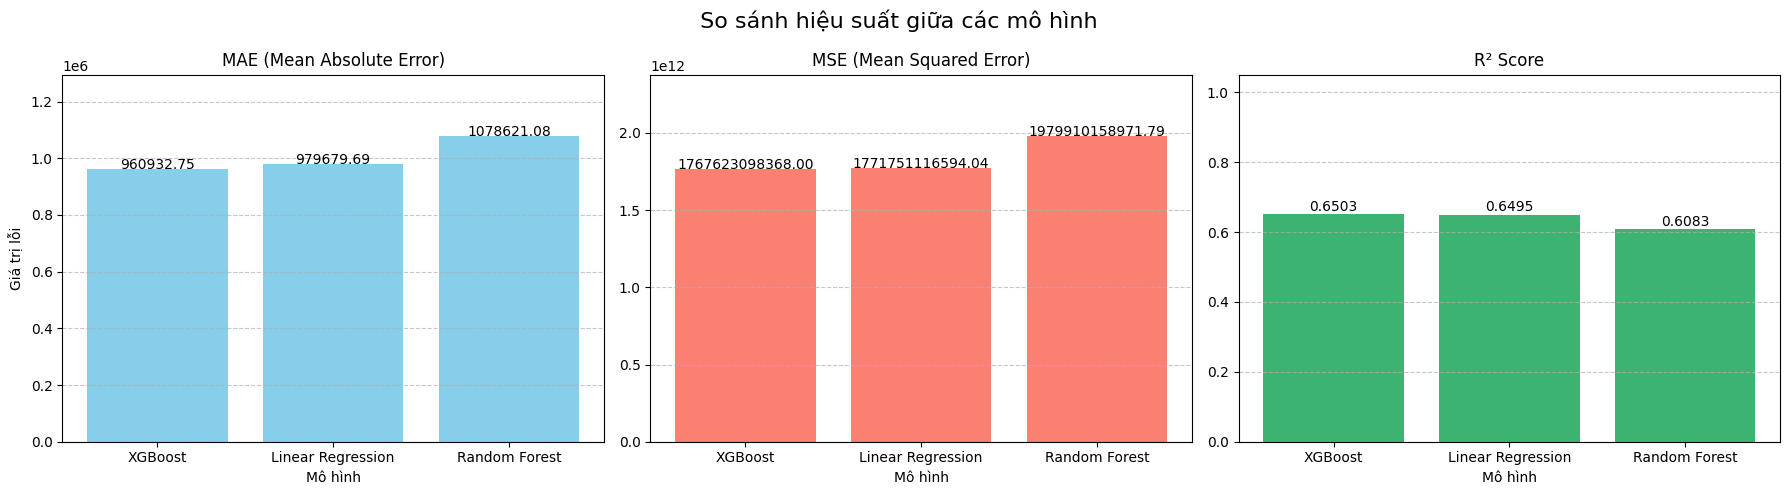

In [15]:
import matplotlib.pyplot as plt

models = ['XGBoost', 'Linear Regression', 'Random Forest']
mae_scores = [mae_xgb, mae_lr, mae_rf]
mse_scores = [mse_xgb, mse_lr, mse_rf]
r2_scores = [r2_xgb, r2_lr, r2_rf]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))


axs[0].bar(models, mae_scores, color='skyblue')
axs[0].set_title('MAE (Mean Absolute Error)')
axs[0].set_ylabel('Giá trị lỗi')
axs[0].set_ylim(0, max(mae_scores) * 1.2)
for i, v in enumerate(mae_scores):
    axs[0].text(i, v + 0.01, f"{v:.2f}", ha='center')

axs[1].bar(models, mse_scores, color='salmon')
axs[1].set_title('MSE (Mean Squared Error)')
axs[1].set_ylim(0, max(mse_scores) * 1.2)
for i, v in enumerate(mse_scores):
    axs[1].text(i, v + 0.01, f"{v:.2f}", ha='center')


axs[2].bar(models, r2_scores, color='mediumseagreen')
axs[2].set_title('R² Score')
axs[2].set_ylim(0, 1.05)
for i, v in enumerate(r2_scores):
    axs[2].text(i, v + 0.01, f"{v:.4f}", ha='center')

for ax in axs:
    ax.set_xlabel('Mô hình')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(' So sánh hiệu suất giữa các mô hình', fontsize=16)
plt.tight_layout()
plt.show()


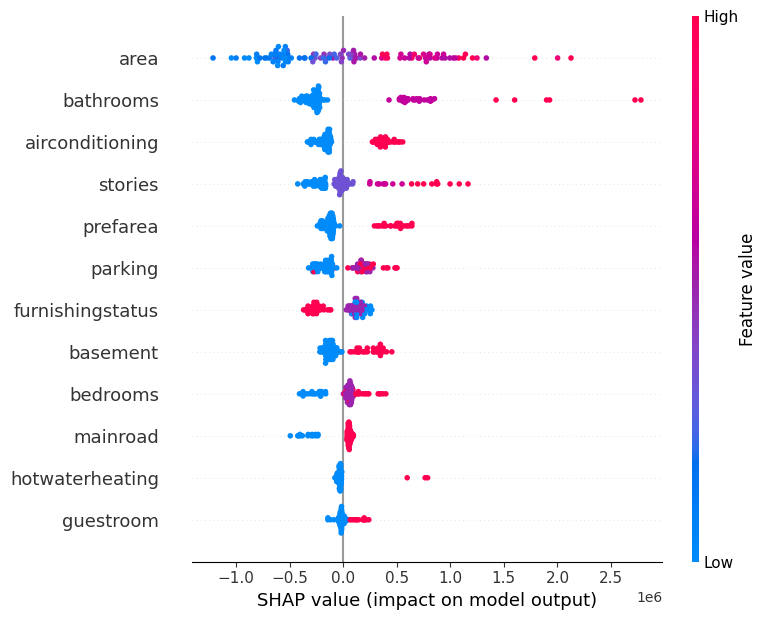

In [16]:
import shap
import pandas as pd


X_test_df = pd.DataFrame(X_test, columns=X_train.columns)


if 'price' in X_test_df.columns:
    X_test_df = X_test_df.drop(columns=['price'])

X_test_df = X_test_df[X_train.columns]

explainer = shap.TreeExplainer(model)


shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)